In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

In [3]:
telecom_df = pd.read_csv('telecom_churn.csv')

In [4]:
telecom_df.head()

,state,account_length,area_code,phone_number,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,class
0,16,128,415,2845,0,1,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,35,107,415,2301,0,1,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,31,137,415,1616,0,0,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,35,84,408,2510,1,0,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,36,75,415,155,1,0,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [5]:
telecom_df.tail()

,state,account_length,area_code,phone_number,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,class
4995,11,50,408,2000,0,1,40,235.7,127,40.07,...,126,18.96,297.5,116,13.39,9.9,5,2.67,2,0
4996,49,152,415,394,0,0,0,184.2,90,31.31,...,73,21.83,213.6,113,9.61,14.7,2,3.97,3,1
4997,7,61,415,313,0,0,0,140.6,89,23.90,...,128,14.69,212.4,97,9.56,13.6,4,3.67,1,0
4998,7,109,510,3471,0,0,0,188.8,67,32.10,...,92,14.59,224.4,89,10.10,8.5,6,2.30,0,0
4999,46,86,415,2412,0,1,34,129.4,102,22.00,...,104,22.70,154.8,100,6.97,9.3,16,2.51,0,0


In [7]:
telecom_df.shape

(5000, 21)

In [8]:
telecom_df.columns

Index(['state', 'account_length', 'area_code', 'phone_number',
       'international_plan', 'voice_mail_plan', 'number_vmail_messages',
       'total_day_minutes', 'total_day_calls', 'total_day_charge',
       'total_eve_minutes', 'total_eve_calls', 'total_eve_charge',
       'total_night_minutes', 'total_night_calls', 'total_night_charge',
       'total_intl_minutes', 'total_intl_calls', 'total_intl_charge',
       'number_customer_service_calls', 'class'],
      dtype='object')

In [9]:
telecom_df.dtypes

state                              int64
account_length                     int64
area_code                          int64
phone_number                       int64
international_plan                 int64
voice_mail_plan                    int64
number_vmail_messages              int64
total_day_minutes                float64
total_day_calls                    int64
total_day_charge                 float64
total_eve_minutes                float64
total_eve_calls                    int64
total_eve_charge                 float64
total_night_minutes              float64
total_night_calls                  int64
total_night_charge               float64
total_intl_minutes               float64
total_intl_calls                   int64
total_intl_charge                float64
number_customer_service_calls      int64
class                              int64
dtype: object

In [11]:
telecom_df.describe()

,state,account_length,area_code,phone_number,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,class
count,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,25.99840,100.25860,436.911400,2499.500000,0.094600,0.264600,7.755200,180.288900,100.029400,30.649668,...,100.191000,17.054322,200.391620,99.919200,9.017732,10.261780,4.435200,2.771196,1.570400,0.141400
std,14.80348,39.69456,42.209182,1443.520003,0.292691,0.441164,13.546393,53.894699,19.831197,9.162069,...,19.826496,4.296843,50.527789,19.958686,2.273763,2.761396,2.456788,0.745514,1.306363,0.348469
min,0.00000,1.00000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.00000,73.00000,408.000000,1249.750000,0.000000,0.000000,0.000000,143.700000,87.000000,24.430000,...,87.000000,14.140000,166.900000,87.000000,7.510000,8.500000,3.000000,2.300000,1.000000,0.000000
50%,26.00000,100.00000,415.000000,2499.500000,0.000000,0.000000,0.000000,180.100000,100.000000,30.620000,...,100.000000,17.090000,200.400000,100.000000,9.020000,10.300000,4.000000,2.780000,1.000000,0.000000
75%,39.00000,127.00000,415.000000,3749.250000,0.000000,1.000000,17.000000,216.200000,113.000000,36.750000,...,114.000000,19.900000,234.700000,113.000000,10.560000,12.000000,6.000000,3.240000,2.000000,0.000000
max,50.00000,243.00000,510.000000,4999.000000,1.000000,1.000000,52.000000,351.500000,165.000000,59.760000,...,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000,1.000000


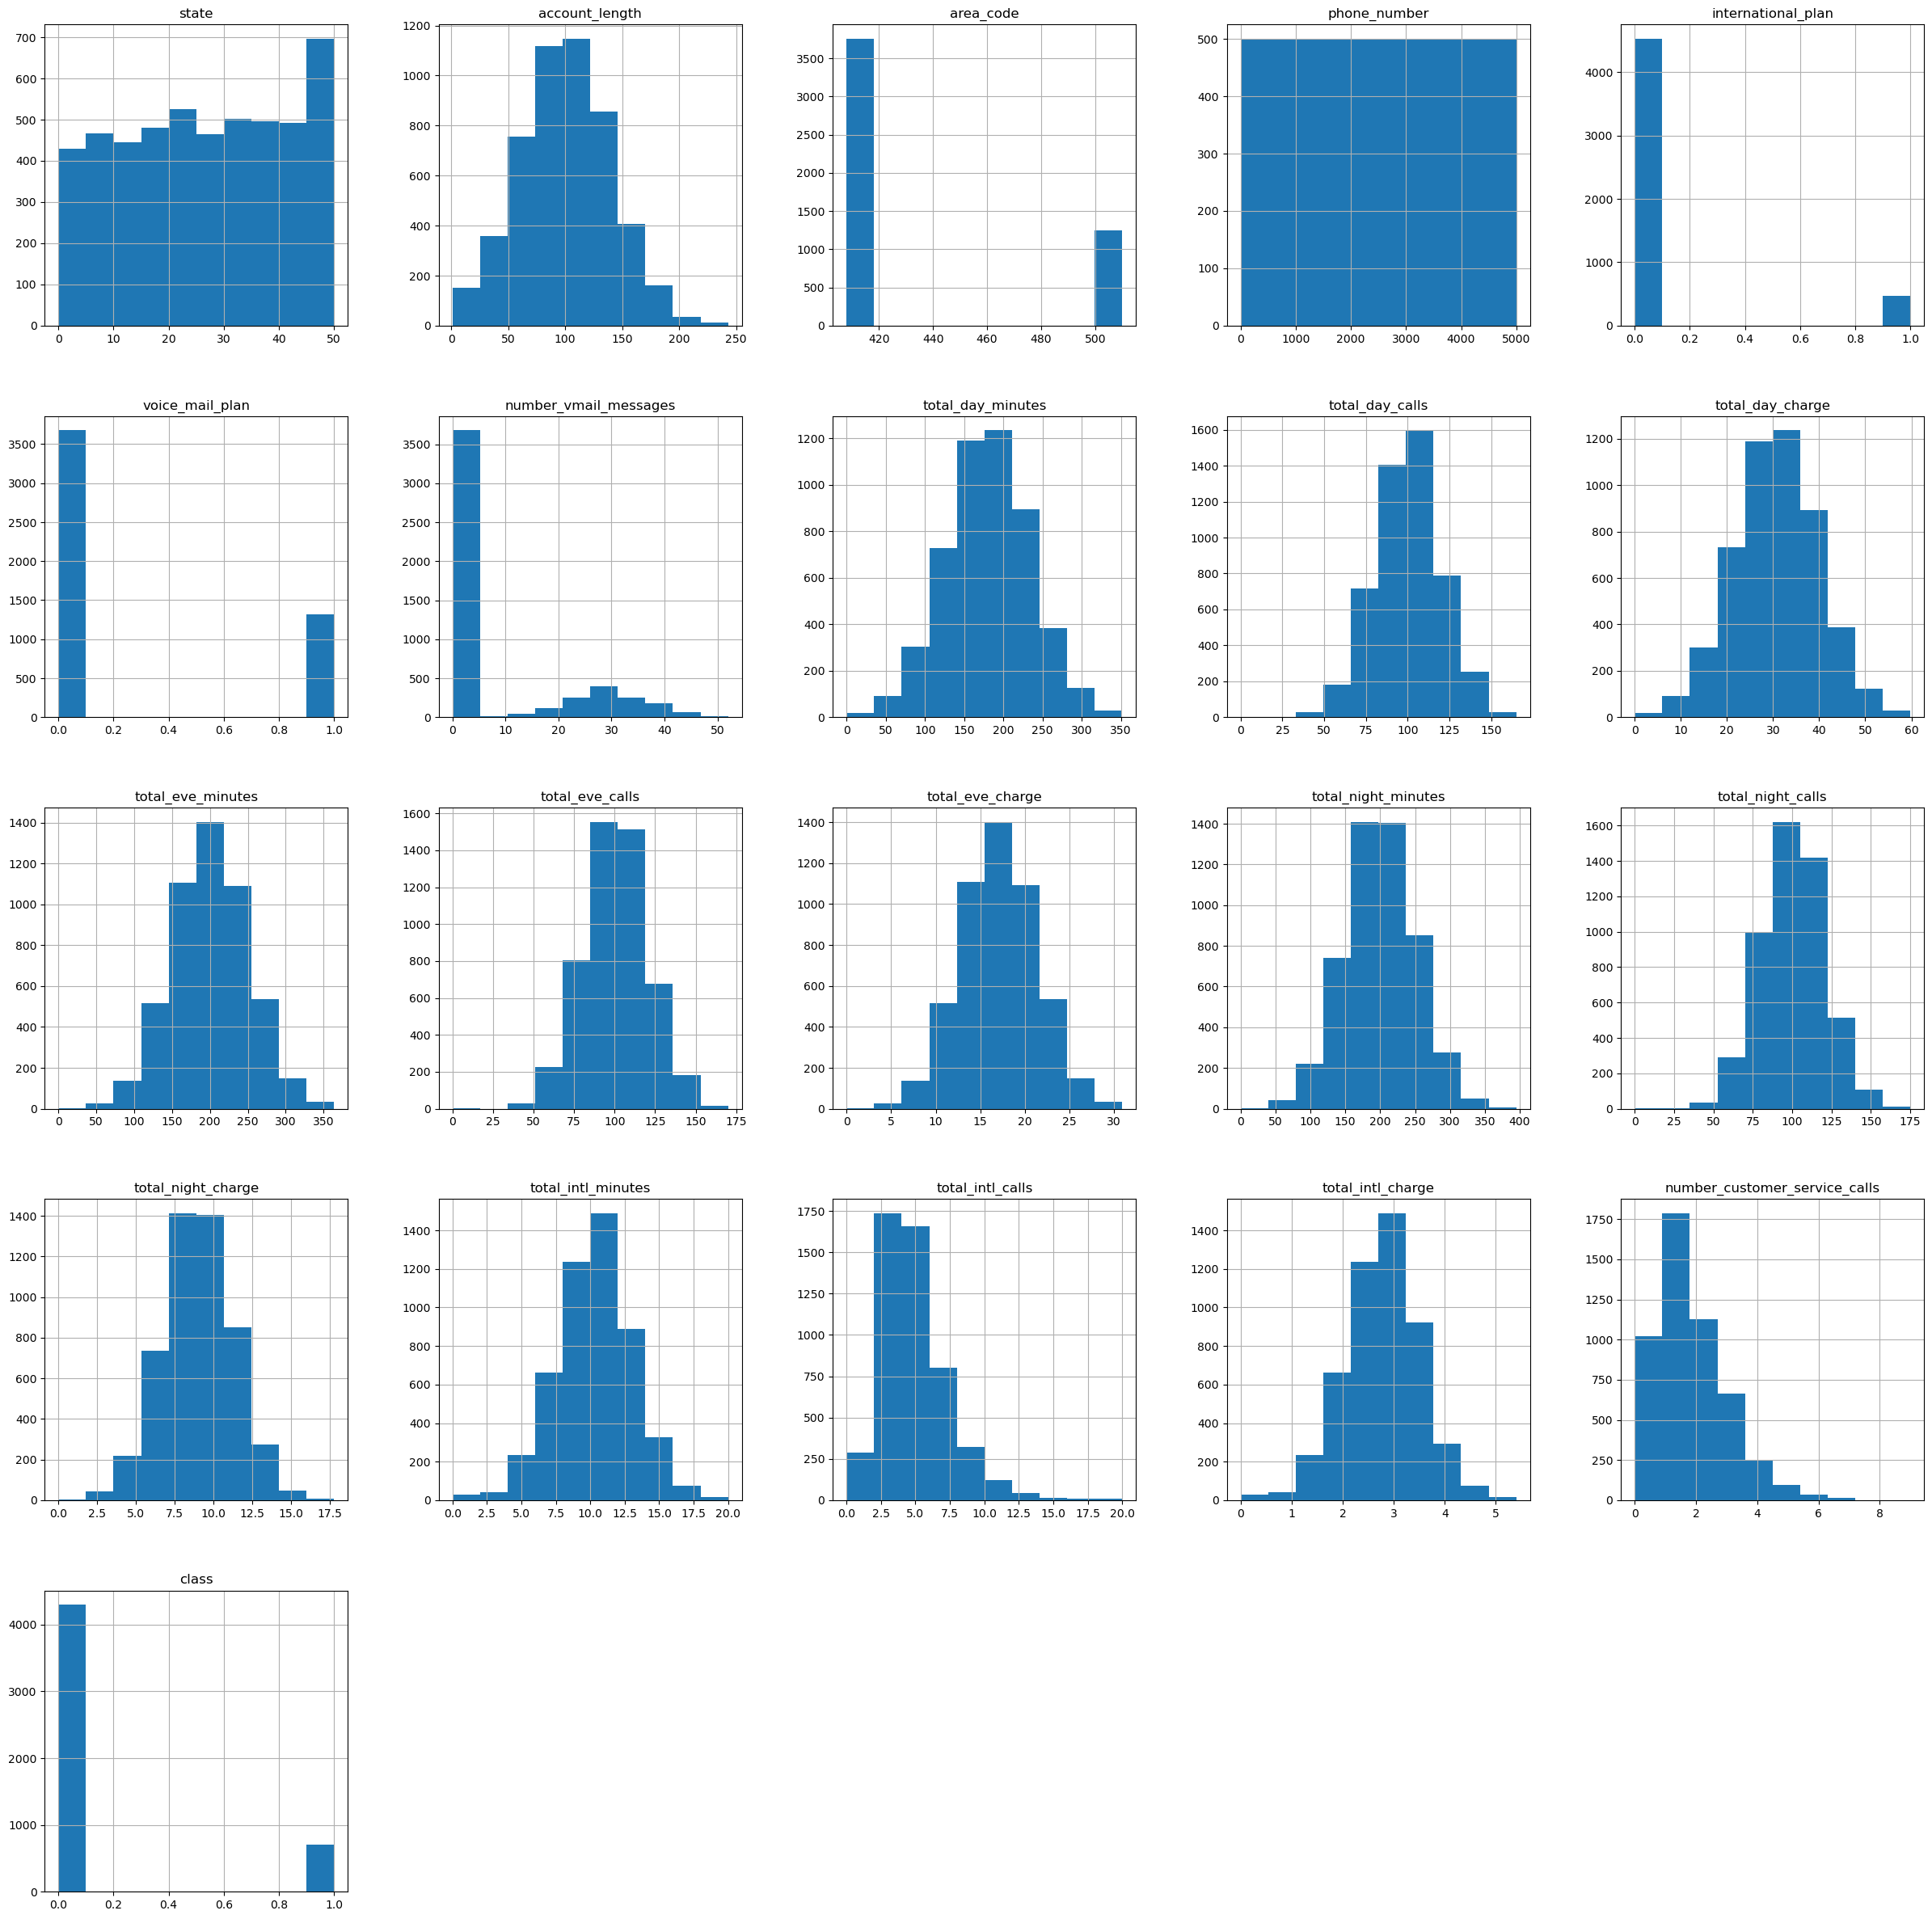

In [13]:
telecom_df.hist(figsize = (30, 30))
plt.show()

In [14]:
telecom_df['class'].value_counts()

class
0    4293
1     707
Name: count, dtype: int64

<Axes: ylabel='count'>

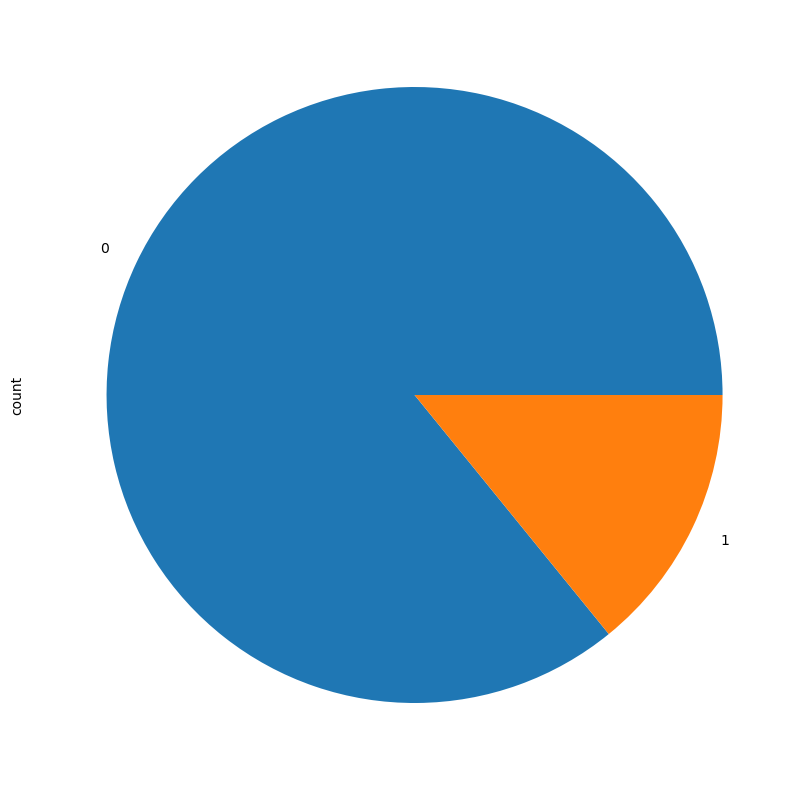

In [16]:
plt.figure(figsize = (10, 10))
telecom_df['class'].value_counts().plot(kind = 'pie')

In [18]:
telecom_df.corr()

,state,account_length,area_code,phone_number,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,class
state,1.000000,0.010334,0.013858,0.017054,0.007422,-0.030075,-0.027282,0.007334,-0.008166,0.007334,...,-0.005458,0.003896,0.009538,-0.001699,0.009532,-0.009313,0.009898,-0.009322,-0.012997,0.006946
account_length,0.010334,1.000000,-0.018054,0.004918,0.014681,-0.006650,-0.014575,-0.001017,0.028240,-0.001019,...,0.009143,-0.009587,0.000668,-0.007825,0.000656,0.001291,0.014277,0.001292,-0.001445,0.021203
area_code,0.013858,-0.018054,1.000000,-0.011648,0.032107,-0.003006,-0.003399,-0.019118,-0.019314,-0.019119,...,-0.012300,0.007114,0.002084,0.014657,0.002070,-0.004154,-0.013623,-0.004219,0.020921,0.010195
phone_number,0.017054,0.004918,-0.011648,1.000000,0.010463,0.014384,0.010649,0.002420,-0.012911,0.002415,...,0.022450,-0.006805,0.008814,0.012723,0.008806,-0.008109,-0.024928,-0.008056,0.028258,0.012371
international_plan,0.007422,0.014681,0.032107,0.010463,1.000000,0.009054,0.011947,0.028138,0.008102,0.028141,...,0.002505,0.021234,-0.026508,0.005623,-0.026510,0.031799,0.004493,0.031751,-0.012974,0.259123
voice_mail_plan,-0.030075,-0.006650,-0.003006,0.014384,0.009054,1.000000,0.954508,0.002059,-0.001735,0.002056,...,-0.005916,0.023332,0.005524,0.009176,0.005522,0.004116,-0.007525,0.004165,-0.014453,-0.110698
number_vmail_messages,-0.027282,-0.014575,-0.003399,0.010649,0.011947,0.954508,1.000000,0.005381,0.000883,0.005377,...,-0.003954,0.019496,0.005541,0.002676,0.005535,0.002463,0.000124,0.002505,-0.007086,-0.097633
total_day_minutes,0.007334,-0.001017,-0.019118,0.002420,0.028138,0.002059,0.005381,1.000000,0.001935,1.000000,...,0.008128,-0.010760,0.011799,0.004236,0.011783,-0.019486,-0.001303,-0.019415,0.002733,0.207705
total_day_calls,-0.008166,0.028240,-0.019314,-0.012911,0.008102,-0.001735,0.000883,0.001935,1.000000,0.001936,...,0.003754,-0.000695,0.002804,-0.008308,0.002802,0.013097,0.010893,0.013161,-0.010739,0.016130
total_day_charge,0.007334,-0.001019,-0.019119,0.002415,0.028141,0.002056,0.005377,1.000000,0.001936,1.000000,...,0.008129,-0.010757,0.011801,0.004235,0.011785,-0.019490,-0.001307,-0.019419,0.002726,0.207700


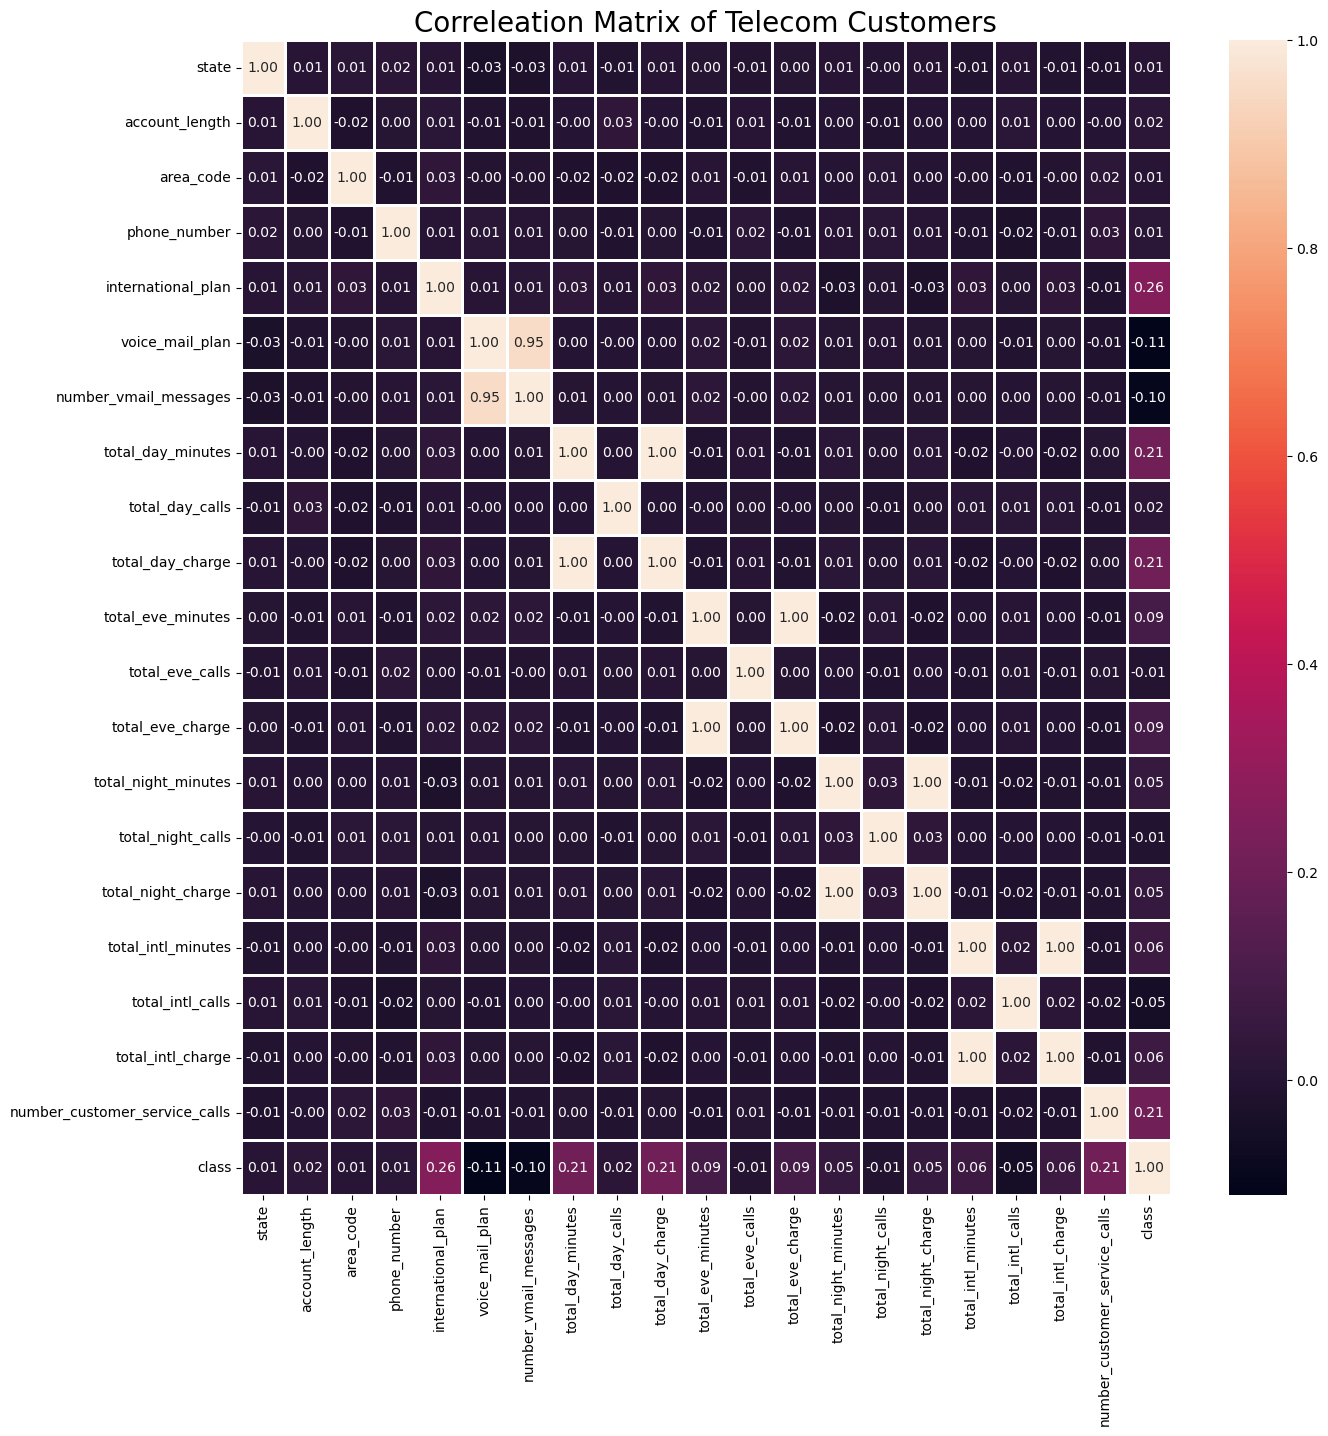

In [21]:
corr_matrix = telecom_df.corr()
plt.figure(figsize = (15, 15))
cm = sns.heatmap(corr_matrix,
                linewidths = 1,
                annot = True,
                fmt = '.2f')

plt.title('Correleation Matrix of Telecom Customers', fontsize = 20)
plt.show()

/var/folders/t7/ysyk1bxd7sjgcsxwz34swgf40000gn/T/ipykernel_54902/200024851.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(telecom_df.total_day_charge[(telecom_df['class']==0)],
/var/folders/t7/ysyk1bxd7sjgcsxwz34swgf40000gn/T/ipykernel_54902/200024851.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(telecom_df.total_day_charge[(telecom_df['class']==1)],


Text(0.5, 1.0, 'Distribution of day charges by churn')

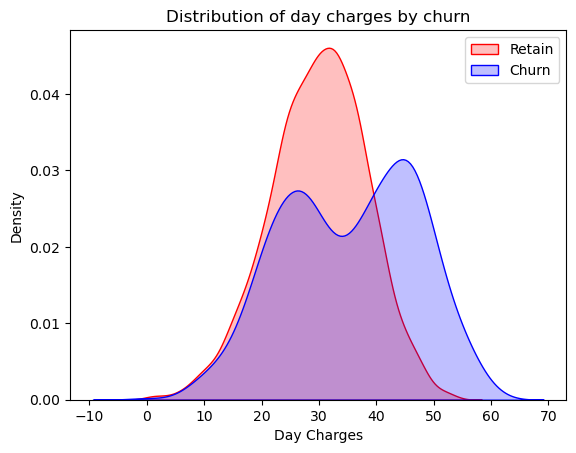

In [22]:
ax = sns.kdeplot(telecom_df.total_day_charge[(telecom_df['class']==0)],
                color = 'red', shade = True)

ax = sns.kdeplot(telecom_df.total_day_charge[(telecom_df['class']==1)],
                color = 'blue', shade = True)

ax.legend(['Retain', 'Churn'], loc = 'upper right')
ax.set_ylabel('Density')
ax.set_xlabel('Day Charges')
ax.set_title("Distribution of day charges by churn")

/var/folders/t7/ysyk1bxd7sjgcsxwz34swgf40000gn/T/ipykernel_54902/758009111.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(telecom_df.total_eve_charge[(telecom_df['class']==0)],
/var/folders/t7/ysyk1bxd7sjgcsxwz34swgf40000gn/T/ipykernel_54902/758009111.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(telecom_df.total_eve_charge[(telecom_df['class']==1)],


Text(0.5, 1.0, 'Distribution of evening charges by churn')

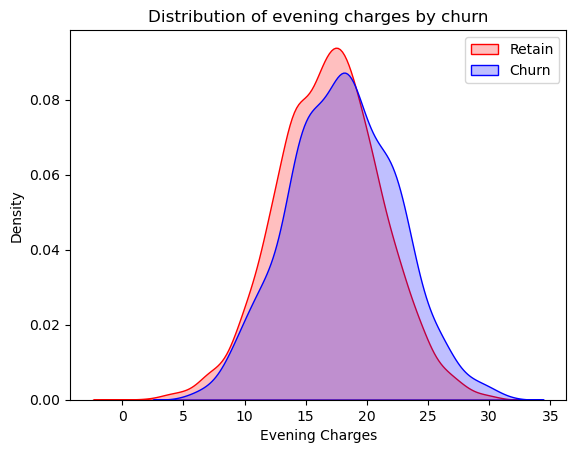

In [23]:
ax = sns.kdeplot(telecom_df.total_eve_charge[(telecom_df['class']==0)],
                color = 'red', shade = True)

ax = sns.kdeplot(telecom_df.total_eve_charge[(telecom_df['class']==1)],
                color = 'blue', shade = True)

ax.legend(['Retain', 'Churn'], loc = 'upper right')
ax.set_ylabel('Density')
ax.set_xlabel('Evening Charges')
ax.set_title("Distribution of evening charges by churn")

In [24]:
# X = input features
# y = output feature

X = telecom_df.drop(['class', 'area_code', 'phone_number'], axis = 'columns')
y = telecom_df['class']

In [25]:
X.shape

(5000, 18)

In [26]:
y.shape

(5000,)

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state =42)

In [30]:
X_train.shape

(3500, 18)

In [31]:
X_test.shape

(1500, 18)

In [35]:
from sklearn.ensemble import RandomForestClassifier

In [40]:
rf = RandomForestClassifier()

In [41]:
rf.fit(X_train, y_train.values.ravel())

RandomForestClassifier()

In [43]:
rf.feature_importances_

array([0.02413812, 0.02761595, 0.07626156, 0.01836481, 0.02993912,
       0.13945848, 0.02600961, 0.14398701, 0.06233625, 0.02809915,
       0.05933323, 0.04116352, 0.02810153, 0.03874229, 0.03682501,
       0.04740226, 0.03914669, 0.13307542])

In [44]:
X.columns

Index(['state', 'account_length', 'international_plan', 'voice_mail_plan',
       'number_vmail_messages', 'total_day_minutes', 'total_day_calls',
       'total_day_charge', 'total_eve_minutes', 'total_eve_calls',
       'total_eve_charge', 'total_night_minutes', 'total_night_calls',
       'total_night_charge', 'total_intl_minutes', 'total_intl_calls',
       'total_intl_charge', 'number_customer_service_calls'],
      dtype='object')

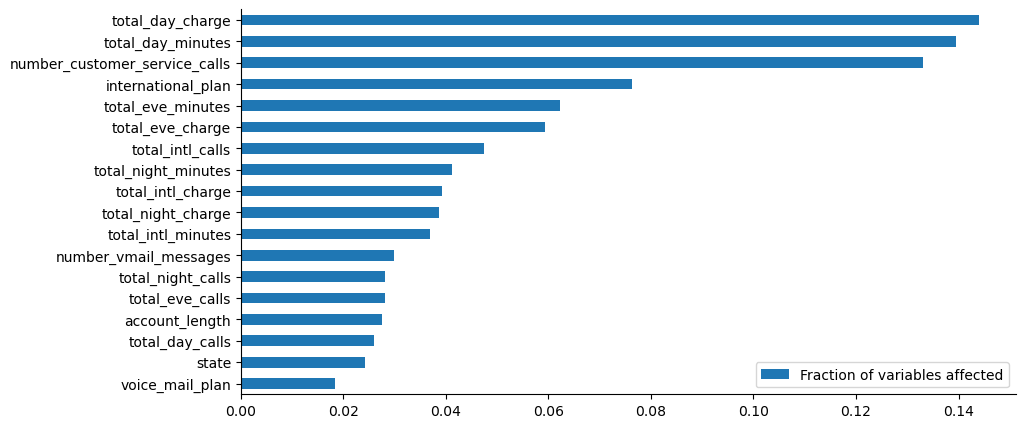

In [46]:
feat_scores= pd.DataFrame({"Fraction of variables affected" : rf.feature_importances_},index = X.columns)
feat_scores= feat_scores.sort_values(by = "Fraction of variables affected")
feat_scores.plot(kind = "barh", figsize = (10, 5))
sns.despine()

In [47]:
#logistic Regression

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [50]:
model_LR = LogisticRegression()
model_LR.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [52]:
y_predict = model_LR.predict(X_test)

In [53]:
y_predict

array([0, 0, 0, ..., 0, 1, 0])

In [54]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1293
           1       0.41      0.10      0.16       207

    accuracy                           0.86      1500
   macro avg       0.64      0.54      0.54      1500
weighted avg       0.81      0.86      0.82      1500



In [55]:
#SVM

In [56]:
from sklearn.calibration import CalibratedClassifierCV

In [57]:
from sklearn.svm import LinearSVC

In [116]:
model_svc = LinearSVC(max_iter = 100000)

In [124]:
model_svm = CalibratedClassifierCV(model_svc)

In [125]:
model_svm.fit(X_train, y_train)

CalibratedClassifierCV(estimator=LinearSVC(max_iter=100000))

In [126]:
y_predict = model_svm.predict(X_test)

In [127]:
y_predict

array([0, 0, 0, ..., 0, 1, 1])

In [128]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      1293
           1       0.58      0.25      0.35       207

    accuracy                           0.87      1500
   macro avg       0.73      0.61      0.64      1500
weighted avg       0.85      0.87      0.85      1500



In [129]:
cm = confusion_matrix(y_test, y_predict)

<Axes: >

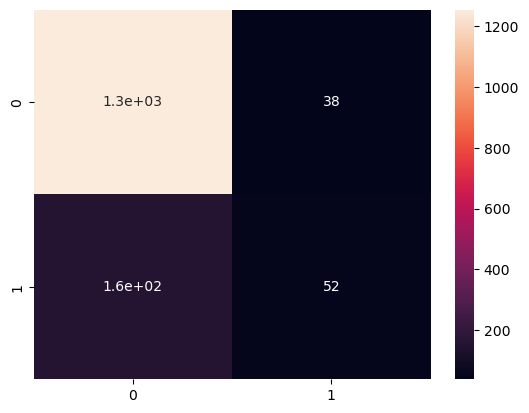

In [130]:
sns.heatmap(cm, annot = True)

In [69]:
#Random Forest 

In [70]:
from sklearn.ensemble import RandomForestClassifier

In [72]:
model_rf = RandomForestClassifier()

In [73]:
model_rf.fit(X_train, y_train)

RandomForestClassifier()

In [77]:
y_predict = model_rf.predict(X_test)

In [78]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1293
           1       0.93      0.74      0.83       207

    accuracy                           0.96      1500
   macro avg       0.94      0.87      0.90      1500
weighted avg       0.96      0.96      0.95      1500



<Axes: >

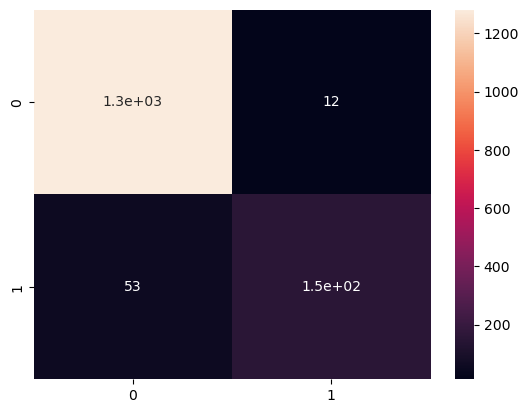

In [79]:
cm = confusion_matrix(y_test, y_predict)
sns.heatmap(cm, annot = True)

In [80]:
#KNN

In [81]:
from sklearn.neighbors import KNeighborsClassifier

In [84]:
model_knn = KNeighborsClassifier()

In [85]:
model_knn.fit(X_train, y_train)

KNeighborsClassifier()

In [86]:
y_predict = model_knn.predict(X_test)

In [88]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1293
           1       0.73      0.33      0.46       207

    accuracy                           0.89      1500
   macro avg       0.82      0.66      0.70      1500
weighted avg       0.88      0.89      0.87      1500



In [89]:
cm = confusion_matrix(y_test, y_predict)

<Axes: >

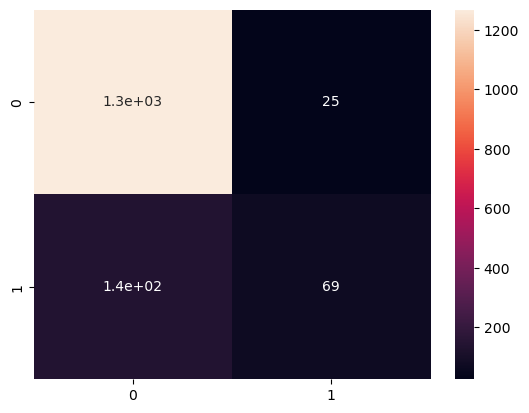

In [90]:
sns.heatmap(cm, annot = True)

In [91]:
#Naive Bayes

In [95]:
from sklearn.naive_bayes import GaussianNB

In [98]:
model_gnb = GaussianNB()

In [99]:
model_gnb.fit(X_train, y_train)

GaussianNB()

In [100]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1293
           1       0.73      0.33      0.46       207

    accuracy                           0.89      1500
   macro avg       0.82      0.66      0.70      1500
weighted avg       0.88      0.89      0.87      1500



<Axes: >

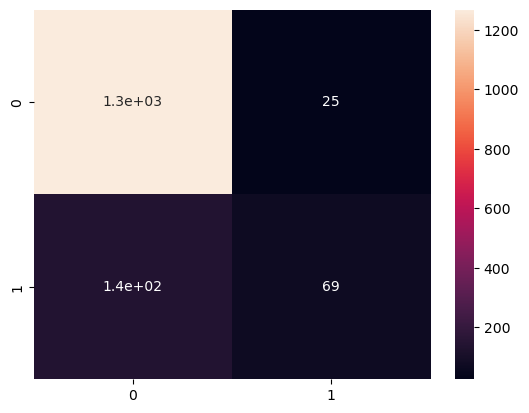

In [101]:
sns.heatmap(confusion_matrix(y_test, y_predict), annot = True)

In [102]:
#plot ROC for all models

In [103]:
model_LR.predict_proba(X_test)

array([[0.88571262, 0.11428738],
       [0.86058599, 0.13941401],
       [0.99091555, 0.00908445],
       ...,
       [0.85666602, 0.14333398],
       [0.14227721, 0.85772279],
       [0.51180845, 0.48819155]])

In [104]:
# Selecting [:, 1] extracts only the probabilities of the positive class (class = 1)
model_LR.predict_proba(X_test)[:, 1]

array([0.11428738, 0.13941401, 0.00908445, ..., 0.14333398, 0.85772279,
       0.48819155])

In [105]:
y_test

1501    0
2586    0
2653    0
1055    0
705     0
       ..
3563    0
1538    1
1837    1
2380    1
1912    1
Name: class, Length: 1500, dtype: int64

In [106]:
fpr1, tpr1, thresh1 = metrics.roc_curve(y_test, model_LR.predict_proba(X_test)[:, 1], pos_label= 1)

In [107]:
fpr1

array([0.        , 0.        , 0.        , 0.00309358, 0.00309358,
       0.00386698, 0.00386698, 0.00464037, 0.00464037, 0.00541377,
       0.00541377, 0.00696056, 0.00696056, 0.00850735, 0.00850735,
       0.01701469, 0.01701469, 0.01778809, 0.01778809, 0.01856148,
       0.01856148, 0.01933488, 0.01933488, 0.02397525, 0.02397525,
       0.02474865, 0.02474865, 0.02552204, 0.02552204, 0.02629544,
       0.02629544, 0.02938902, 0.02938902, 0.0317092 , 0.0317092 ,
       0.0324826 , 0.0324826 , 0.03325599, 0.03325599, 0.03402939,
       0.03402939, 0.03480278, 0.03480278, 0.03634957, 0.03634957,
       0.03789637, 0.03789637, 0.04098995, 0.04098995, 0.04253674,
       0.04253674, 0.04331013, 0.04331013, 0.04408353, 0.04408353,
       0.04563032, 0.04563032, 0.04640371, 0.04640371, 0.04717711,
       0.04717711, 0.0487239 , 0.0487239 , 0.04949729, 0.04949729,
       0.05027069, 0.05027069, 0.05336427, 0.05336427, 0.05413766,
       0.05413766, 0.05645785, 0.05645785, 0.05800464, 0.05800

In [110]:
tpr1

array([0.        , 0.00483092, 0.01932367, 0.01932367, 0.02415459,
       0.02415459, 0.04347826, 0.04347826, 0.04830918, 0.04830918,
       0.0531401 , 0.0531401 , 0.05797101, 0.05797101, 0.06280193,
       0.06280193, 0.0821256 , 0.0821256 , 0.08695652, 0.08695652,
       0.09178744, 0.09178744, 0.09661836, 0.09661836, 0.10628019,
       0.10628019, 0.12077295, 0.12077295, 0.1352657 , 0.1352657 ,
       0.14492754, 0.14492754, 0.15458937, 0.15458937, 0.16425121,
       0.16425121, 0.17391304, 0.17391304, 0.18357488, 0.18357488,
       0.19806763, 0.19806763, 0.20289855, 0.20289855, 0.21256039,
       0.21256039, 0.2173913 , 0.2173913 , 0.23188406, 0.23188406,
       0.23671498, 0.23671498, 0.25120773, 0.25120773, 0.25603865,
       0.25603865, 0.26086957, 0.26086957, 0.2705314 , 0.2705314 ,
       0.28019324, 0.28019324, 0.28985507, 0.28985507, 0.29468599,
       0.29468599, 0.29951691, 0.29951691, 0.30434783, 0.30434783,
       0.31884058, 0.31884058, 0.3236715 , 0.3236715 , 0.32850

In [111]:
thresh1

array([       inf, 0.89609847, 0.85772279, 0.77181007, 0.74997545,
       0.74878224, 0.71892872, 0.69296734, 0.69137714, 0.68735903,
       0.6706717 , 0.65400553, 0.63777322, 0.63082689, 0.62707437,
       0.56690016, 0.54813437, 0.54737217, 0.54566035, 0.54046323,
       0.53724084, 0.53661153, 0.53654572, 0.49683691, 0.48819155,
       0.48531268, 0.48139212, 0.47927788, 0.47677483, 0.46917916,
       0.46681042, 0.4588088 , 0.45808115, 0.45356098, 0.45072811,
       0.44807793, 0.44311053, 0.43806267, 0.43593457, 0.43305082,
       0.42545875, 0.42498466, 0.42392116, 0.42235163, 0.4211395 ,
       0.42043003, 0.41649004, 0.41096333, 0.40643224, 0.40518901,
       0.40287718, 0.39933347, 0.39300055, 0.38952885, 0.38912452,
       0.38601299, 0.38450331, 0.3842203 , 0.38222843, 0.37914608,
       0.37757682, 0.37204835, 0.37060521, 0.36944576, 0.36941618,
       0.36795613, 0.36480461, 0.36113601, 0.36015029, 0.3597522 ,
       0.35334107, 0.35172062, 0.349245  , 0.34617229, 0.34550

In [112]:
#Roc

In [131]:
from sklearn.metrics import roc_curve

fpr1, tpr1, thresh1 = roc_curve(y_test, model_LR.predict_proba(X_test)[:, 1], pos_label = 1)
fpr2, tpr2, thresh2 = roc_curve(y_test, model_svm.predict_proba(X_test)[:, 1], pos_label = 1)
fpr3, tpr3, thresh3 = roc_curve(y_test, model_rf.predict_proba(X_test)[:, 1], pos_label = 1)
fpr4, tpr4, thresh4 = roc_curve(y_test, model_knn.predict_proba(X_test)[:, 1], pos_label = 1)
fpr5, tpr5, thresh5 = roc_curve(y_test, model_gnb.predict_proba(X_test)[:, 1], pos_label = 1)

In [132]:
# AUC

from sklearn.metrics import roc_auc_score

auc_score1 = roc_auc_score(y_test, model_LR.predict_proba(X_test)[:, 1])
auc_score2 = roc_auc_score(y_test, model_svm.predict_proba(X_test)[:, 1])
auc_score3 = roc_auc_score(y_test, model_rf.predict_proba(X_test)[:, 1])
auc_score4 = roc_auc_score(y_test, model_knn.predict_proba(X_test)[:, 1])
auc_score5 = roc_auc_score(y_test, model_gnb.predict_proba(X_test)[:, 1])

print("Logistic Regression: ", auc_score1) # Logistic Regression
print("Support Vector Machine: ", auc_score2) # Support Vector Machine
print("Random Forest: ", auc_score3) # Random Forest
print("K-Nearest Neighbors: ", auc_score4) # K-Nearest Neighbors
print("Naive Bayes: ", auc_score5) # Naive Bayes

Logistic Regression:  0.7537165936237863
Support Vector Machine:  0.8322292836567022
Random Forest:  0.9215975281243112
K-Nearest Neighbors:  0.6927454035292229
Naive Bayes:  0.8523599762377125


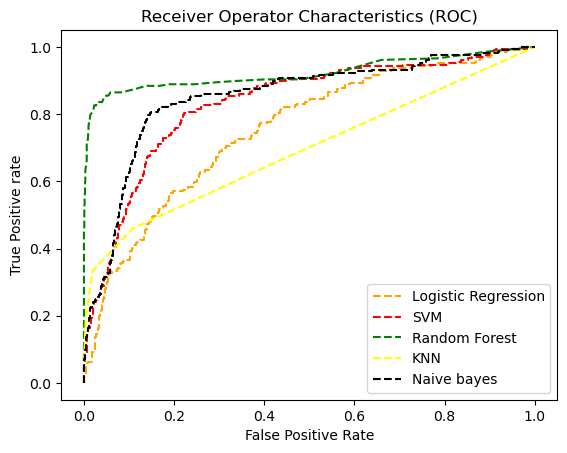

In [133]:
plt.plot(fpr1, tpr1, linestyle = "--", color = "orange", label = "Logistic Regression")
plt.plot(fpr2, tpr2, linestyle = "--", color = "red", label = "SVM")
plt.plot(fpr3, tpr3, linestyle = "--", color = "green", label = "Random Forest")
plt.plot(fpr4, tpr4, linestyle = "--", color = "yellow", label = "KNN")
plt.plot(fpr5, tpr5, linestyle = "--", color = "black", label = "Naive bayes")

plt.title('Receiver Operator Characteristics (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')

plt.legend(loc = 'best')
plt.savefig('ROC', dpi = 300)
plt.show()